---
title: "Python 基础入门(5)"
description: "本内容面向的读者是没有编程经验的纯编程小白，可以帮助你学习 Python 基础"
date: 2026-09-01

categories:
  - Python
  - Code
---

## 类与面向对象

前面几篇教程里，我们一直用 Python 的内置类型来存数据：列表存一组数字，字典存键值对，字符串存文本。这些内置类型够用，但当你想把「一组相关的数据和操作」打包在一起的时候，就需要自己定义类型了。

比如你想表示一个学生，有姓名、年龄、成绩，还能算平均分。你可以用字典 `{"name": "Alice", "age": 20, "scores": [90, 85, 92]}` 来凑合，但操作起来不方便，代码也不直观。用类（class）来做就优雅多了。

这篇讲 Python 面向对象的基础：类的定义、继承、魔术方法。内容不多，但理解了这些，后面看到别人的代码就不会懵了。

### 类的定义

用 `class` 关键字定义一个类。类就是一个模板，定义了这类对象有什么属性 **（数据）** 和什么方法 **（操作）**。

```{pyodide}
#| caption: "定义一个类"
class Student:
    # __init__ 是构造方法，创建对象时自动调用
    # self 指向当前对象本身，类似其他语言的 this
    def __init__(self, name, age):
        # 给对象绑定属性
        self.name = name
        self.age = age
        self.scores = []

    # 定义方法：添加成绩
    def add_score(self, score):
        self.scores.append(score)

    # 定义方法：计算平均分
    def average(self):
        if not self.scores:
            return 0
        return sum(self.scores) / len(self.scores)

# 创建对象（实例化）
alice = Student("Alice", 20)
bob = Student("Bob", 21)

# 调用方法
alice.add_score(90)
alice.add_score(85)
alice.add_score(92)

bob.add_score(78)
bob.add_score(88)

# 访问属性和调用方法
# 输出：Alice 的平均分：89.0
print(f"{alice.name} 的平均分：{alice.average()}")
# 输出：Bob 的平均分：83.0
print(f"{bob.name} 的平均分：{bob.average()}")
```

几个关键点：

`__init__` 是构造方法，每次用 `Student("Alice", 20)` 创建对象时，Python 会自动调用它。你在里面用 `self.xxx = xxx` 给对象绑定属性。

`self` 是每个方法的第一个参数，指向当前对象本身。调用 `alice.add_score(90)` 时，Python 自动把 `alice` 传给 `self`，你不需要手动传。

如果你写过 Java 或 C++，`self` 就相当于 `this`，只不过 Python 要求显式写出来。

你可能会好奇：方法定义时写了 `self`，调用时却不用传，这不是参数对不上吗？这其实是 Python 的语法规则，`alice.add_score(90)` 在底层等价于 `Student.add_score(alice, 90)`，Python 帮你把对象自动传进去了。

### 属性的访问和修改

Python 的对象属性是完全开放的，可以随时读取和修改，也可以动态添加新属性：

```{pyodide}
#| caption: "属性的访问和修改"
class Dog:
    def __init__(self, name, breed):
        self.name = name
        self.breed = breed

dog = Dog("旺财", "柴犬")

# 读取属性
# 输出：旺财 是一只 柴犬
print(f"{dog.name} 是一只 {dog.breed}")

# 修改属性
dog.name = "大黄"
# 输出：大黄
print(dog.name)

# Python 甚至允许动态添加属性
dog.age = 3
# 输出：大黄 今年 3 岁
print(f"{dog.name} 今年 {dog.age} 岁")
```

Python 没有 Java 的 `private`、`protected` 这些访问控制关键字。约定俗成的做法是：以下划线开头的属性（如 `_name`）表示「不建议外部直接访问」，但这只是君子协定，Python 不会真的阻止你。

### 继承

继承就是 **「在已有类的基础上扩展」** 。子类自动拥有父类的所有属性和方法，还可以添加新的或者重写已有的。

```{pyodide}
#| caption: "继承基础"
# 父类
class Animal:
    def __init__(self, name):
        self.name = name

    def speak(self):
        return "..."

# 子类：括号里写父类名
class Cat(Animal):
    def speak(self):
        return "喵~"

class Dog(Animal):
    def speak(self):
        return "汪！"

# 子类自动拥有父类的 __init__，所以可以传 name
cat = Cat("小花")
dog = Dog("旺财")

# 输出：小花 说：喵~
print(f"{cat.name} 说：{cat.speak()}")
# 输出：旺财 说：汪！
print(f"{dog.name} 说：{dog.speak()}")
```

`Cat(Animal)` 表示 Cat 继承自 Animal。Cat 没有定义 `__init__`，所以自动用 Animal 的。Cat 重写了 `speak()` 方法，调用时会用 Cat 自己的版本。可以自己改动父类的方法名称，再试试看输出是怎么样的呢。

如果子类需要在父类的基础上扩展 `__init__`，可以用 `super()` 调用父类的方法：

```{pyodide}
#| caption: "super() 调用父类方法"
class Animal:
    def __init__(self, name):
        self.name = name

    def info(self):
        return f"名字：{self.name}"

class Pet(Animal):
    def __init__(self, name, owner):
        # 先调用父类的 __init__，设置 name
        super().__init__(name)
        # 再设置子类特有的属性
        self.owner = owner

    # 重写 info 方法，在父类基础上扩展
    def info(self):
        # 调用父类的 info 方法
        base_info = super().info()
        return f"{base_info}，主人：{self.owner}"

pet = Pet("小白", "张三")
# 输出：名字：小白，主人：张三
print(pet.info())
```

`super()` 返回一个代理对象，通过它可以调用父类的方法。`super().__init__(name)` 就是调用父类 `Animal` 的 `__init__`，确保 `name` 属性被正确设置，然后子类再添加自己的 `owner` 属性。

### 魔术方法

Python 类里有一些以双下划线开头和结尾的特殊方法，叫做**魔术方法**（也叫 dunder methods，double underscore 的缩写）。它们不是你直接调用的，而是 Python 在特定场景下自动调用。

前面已经见过 `__init__`，它在创建对象时自动触发。下面再来看几个最常用的。

#### `__str__` 和 `__repr__`

当你 `print()` 一个对象，或者在交互式环境里直接输入对象名时，Python 会调用这两个方法来决定「怎么显示这个对象」。

```{pyodide}
#| caption: "没有__str__ vs 有__str__"
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

# 没定义 __str__，打印出来是一串看不懂的东西
p = Point(3, 4)
# 输出类似：<__main__.Point object at 0x...>
print(p)

class BetterPoint:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __str__(self):
        return f"Point({self.x}, {self.y})"

    def __repr__(self):
        return f"BetterPoint({self.x}, {self.y})"

p2 = BetterPoint(3, 4)
# print() 调用 __str__
# 输出：Point(3, 4)
print(p2)

# 直接看变量（或在列表中）调用 __repr__
# 输出：[BetterPoint(3, 4), BetterPoint(1, 2)]
print([p2, BetterPoint(1, 2)])
```

`__str__` 是给人看的，`print()` 和 `str()` 会调用它。`__repr__` 是给开发者看的，在交互式环境和容器（列表、字典）中显示时使用。

如果只定义一个，优先定义 `__repr__`，因为 `__str__` 没定义时 Python 会退而求其次调用 `__repr__`。

#### `__len__` 和 `__getitem__`

定义了 `__len__`，你的对象就能用 `len()` 函数。定义了 `__getitem__`，就能用 `[]` 下标访问。

```{pyodide}
#| caption: "让自定义对象支持len()和[]"
class Deck:
    # 三引号字符串写在类/函数的第一行，叫文档字符串（docstring）
    # 用于描述它的用途，可以通过 __doc__ 属性访问
    """一副简化的扑克牌"""
    def __init__(self):
        suits = ["黑桃", "红心", "梅花", "方块"]
        ranks = ["A", "2", "3", "4", "5", "6", "7",
                 "8", "9", "10", "J", "Q", "K"]
        self.cards = [f"{s}{r}" for s in suits for r in ranks]

    def __len__(self):
        return len(self.cards)

    def __getitem__(self, index):
        return self.cards[index]

deck = Deck()

# len() 自动调用 __len__
# 输出：一副牌有 52 张
print(f"一副牌有 {len(deck)} 张")

# [] 自动调用 __getitem__
# 输出：第一张：黑桃A
print(f"第一张：{deck[0]}")
# 输出：最后一张：方块K
print(f"最后一张：{deck[-1]}")

# 甚至支持切片
# 输出：前三张：['黑桃A', '黑桃2', '黑桃3']
print(f"前三张：{deck[:3]}")

# 定义了 __getitem__ 后，还能直接用 for 循环遍历
for card in deck[:5]:
    print(card, end=" ")
# 输出：黑桃A 黑桃2 黑桃3 黑桃4 黑桃5
print()
```

这就是 Python 的哲学：通过实现特定的魔术方法，让你的自定义对象像内置类型一样使用。`len()`、`[]`、`for` 循环这些操作本质上都是在调用对象的魔术方法。

#### `__eq__` 和 `__lt__`

定义了 `__eq__` 就能用 `==` 比较两个对象，定义了 `__lt__` 就能用 `<` 比较，同时 `sorted()` 排序也能自动工作。

```{pyodide}
#| caption: "让自定义对象支持比较和排序"
class Student:
    def __init__(self, name, score):
        self.name = name
        self.score = score

    def __repr__(self):
        return f"{self.name}({self.score})"

    # 定义 == 的行为
    def __eq__(self, other):
        return self.score == other.score

    # 定义 < 的行为
    def __lt__(self, other):
        return self.score < other.score

a = Student("Alice", 90)
b = Student("Bob", 85)
c = Student("Charlie", 90)

# == 调用 __eq__
# 输出：Alice == Charlie? True
print(f"Alice == Charlie? {a == c}")
# 输出：Alice == Bob? False
print(f"Alice == Bob? {a == b}")

# < 调用 __lt__
# 输出：Bob < Alice? True
print(f"Bob < Alice? {b < a}")

# 定义了 __lt__ 后，sorted() 就能排序了
students = [a, b, c]
ranked = sorted(students)
# 输出：从低到高：[Bob(85), Alice(90), Charlie(90)]
print(f"从低到高：{ranked}")

ranked_desc = sorted(students, reverse=True)
# 输出：从高到低：[Alice(90), Charlie(90), Bob(85)]
print(f"从高到低：{ranked_desc}")
```

`sorted()` 排序只需要 `__lt__` 就够了。当你写 `a > b` 时，如果 `a` 没有定义 `__gt__`，Python 会回退尝试 `b`.`__lt__(a)`，所以只定义 `__lt__` 也能让 `>` 工作。

但只定义 `__lt__` 并不能让 `<=`、`>=` 自动工作，因为 Python 不会从 `__lt__` 和 `__eq__` 推导出 `__le__`。

如果觉得每个都写太麻烦，可以用标准库的 `functools.total_ordering`，只需要定义 `__eq__` 加上 `__lt__`/`__gt__`/`__le__`/`__ge__` 中的任意一个，就能自动补全其余的比较方法。

### 常见的魔术方法速查

前面讲了最常用的几个魔术方法，这里汇总一下，方便你查阅：

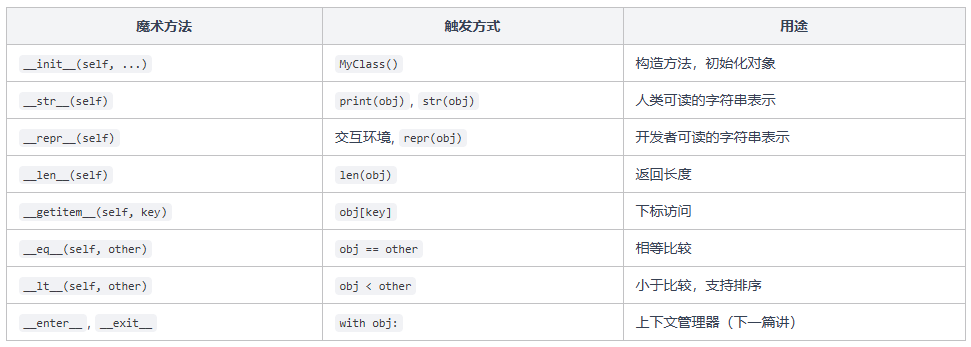

Python 的魔术方法远不止这些，但常用的就这些。说白了，**Python 的运算符和内置函数（`len`、`print`、`sorted`、`[]` 等）本质上都是在调用对象的魔术方法** 。 你给自定义类实现了这些方法，它就能像内置类型一样使用。

### 小结

这篇讲了 Python 面向对象的核心内容。`class` 把数据和操作打包在一起，`__init__` 负责初始化，`self` 指向当前对象。继承让你在已有类的基础上扩展，`super()` 调用父类的方法。

魔术方法是 Python 面向对象的精髓：通过实现 `__str__`、`__len__`、`__eq__` 这些方法，你的自定义对象就能融入 Python 的内置体系，用 `print()`、`len()`、`==`、`sorted()` 来操作。